<a href="https://colab.research.google.com/github/Redcoder815/Machine_learning_phitron/blob/main/22HappinessbytheNumbers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

25.
You are asked to predict a country's happiness score. You have 'Social
support', 'Healthy life expectancy', and 'Freedom to make life choices' as features.
Explain conceptually whether you expect these will impact a man happiness score

26.
A student concludes from a scatterplot that 'high GDP causes high happiness'.
Critique this conclusion. Explain your thoughts
�
�
Practical

27.
Load the dataset. Identify the top 10 and bottom 10 happiest countries. Create
a horizontal bar chart showing both groups side-by-side with different colors.

28.
Create a scatterplot of 'Logged GDP per capita' vs 'Ladder score'. Add a
regression line using sns.regplot().

29.
Perform regional analysis: group by 'Regional indicator' and compute the
mean of all numeric columns. Visualize mean happiness by region using a barplot
sorted by score. Which region has the highest variance in happiness? Use a boxplot
to verify.
SURPRISE BONUS CHALL


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [2]:
df = pd.read_csv('/content/world-happiness-report.csv')
df

,Country name,year,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect
0,Afghanistan,2008,3.724,7.370,0.451,50.80,0.718,0.168,0.882,0.518,0.258
1,Afghanistan,2009,4.402,7.540,0.552,51.20,0.679,0.190,0.850,0.584,0.237
2,Afghanistan,2010,4.758,7.647,0.539,51.60,0.600,0.121,0.707,0.618,0.275
3,Afghanistan,2011,3.832,7.620,0.521,51.92,0.496,0.162,0.731,0.611,0.267
4,Afghanistan,2012,3.783,7.705,0.521,52.24,0.531,0.236,0.776,0.710,0.268
...,...,...,...,...,...,...,...,...,...,...,...
1944,Zimbabwe,2016,3.735,7.984,0.768,54.40,0.733,-0.095,0.724,0.738,0.209
1945,Zimbabwe,2017,3.638,8.016,0.754,55.00,0.753,-0.098,0.751,0.806,0.224
1946,Zimbabwe,2018,3.616,8.049,0.775,55.60,0.763,-0.068,0.844,0.710,0.212
1947,Zimbabwe,2019,2.694,7.950,0.759,56.20,0.632,-0.064,0.831,0.716,0.235


In [3]:
df1 = pd.read_csv('/content/world-happiness-report-2021.csv')
df1

,Country name,Regional indicator,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Finland,Western Europe,7.842,0.032,7.904,7.780,10.775,0.954,72.000,0.949,-0.098,0.186,2.43,1.446,1.106,0.741,0.691,0.124,0.481,3.253
1,Denmark,Western Europe,7.620,0.035,7.687,7.552,10.933,0.954,72.700,0.946,0.030,0.179,2.43,1.502,1.108,0.763,0.686,0.208,0.485,2.868
2,Switzerland,Western Europe,7.571,0.036,7.643,7.500,11.117,0.942,74.400,0.919,0.025,0.292,2.43,1.566,1.079,0.816,0.653,0.204,0.413,2.839
3,Iceland,Western Europe,7.554,0.059,7.670,7.438,10.878,0.983,73.000,0.955,0.160,0.673,2.43,1.482,1.172,0.772,0.698,0.293,0.170,2.967
4,Netherlands,Western Europe,7.464,0.027,7.518,7.410,10.932,0.942,72.400,0.913,0.175,0.338,2.43,1.501,1.079,0.753,0.647,0.302,0.384,2.798
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144,Lesotho,Sub-Saharan Africa,3.512,0.120,3.748,3.276,7.926,0.787,48.700,0.715,-0.131,0.915,2.43,0.451,0.731,0.007,0.405,0.103,0.015,1.800
145,Botswana,Sub-Saharan Africa,3.467,0.074,3.611,3.322,9.782,0.784,59.269,0.824,-0.246,0.801,2.43,1.099,0.724,0.340,0.539,0.027,0.088,0.648
146,Rwanda,Sub-Saharan Africa,3.415,0.068,3.548,3.282,7.676,0.552,61.400,0.897,0.061,0.167,2.43,0.364,0.202,0.407,0.627,0.227,0.493,1.095
147,Zimbabwe,Sub-Saharan Africa,3.145,0.058,3.259,3.030,7.943,0.750,56.201,0.677,-0.047,0.821,2.43,0.457,0.649,0.243,0.359,0.157,0.075,1.205


Conceptual Impact of the Features on Happiness Score

All three features are expected to have a strong positive impact on a country's happiness score. According to psychological and economic frameworks (like the World Happiness Report), these variables represent core foundations of human well-being.

1. Social SupportConcept: Measured as having relatives or friends to count on during times of trouble.Impact: High Positive Impact.Reason: This provides a psychological safety net. High social support reduces stress, fosters community trust, and fulfills the fundamental human need for belonging.

2. Healthy Life ExpectancyConcept: The average number of years a newborn is expected to live in good health.Impact: High Positive Impact.Reason: Physical health is a prerequisite for enjoying life. Chronic illness, poor healthcare systems, and low life expectancy heavily drain a population's mental well-being and productivity.

3. Freedom to Make Life ChoicesConcept: The national average of satisfaction with the freedom to choose what to do with one's life.Impact: Moderate-to-High Positive Impact.Reason: Autonomy and liberty are crucial for individual fulfillment. When citizens feel trapped by systemic restrictions, corruption, or lack of opportunity, average happiness scores drop significantly.

The student’s conclusion commits a fundamental statistical error: Correlation does not imply causation.

A scatterplot only shows an association or directional trend between two variables. It cannot prove that one variable actively drives or creates changes in the other.

1. Confounding Variables (The Third-Variable Problem)A third, unmeasured factor might actually drive both higher GDP and higher happiness. For example:Strong Institutional Trust & Good Governance: Low corruption and high political stability help an economy grow (high GDP) and simultaneously make citizens feel secure and content (high happiness).Strong Healthcare Systems: A healthy population is more productive at work and enjoys a better quality of life.

2. Reverse CausalityThe causal arrow could point in the opposite direction, or work in a loop:Happy, healthy, and low-stress populations are typically more productive, innovative, and cooperative. This baseline well-being can actually be a driver of economic growth and high GDP, rather than just a byproduct of it.

3. The Easterlin ParadoxEconomic data shows that within a single country, richer people are generally happier than poorer people. However, over long periods, as a whole country's GDP grows over time, the average national happiness level often stagnates or flattens out. This proves that absolute wealth accumulation alone does not continuously manufacture happiness.

In [4]:
df1.head(10)

,Country name,Regional indicator,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Finland,Western Europe,7.842,0.032,7.904,7.780,10.775,0.954,72.0,0.949,-0.098,0.186,2.43,1.446,1.106,0.741,0.691,0.124,0.481,3.253
1,Denmark,Western Europe,7.620,0.035,7.687,7.552,10.933,0.954,72.7,0.946,0.030,0.179,2.43,1.502,1.108,0.763,0.686,0.208,0.485,2.868
2,Switzerland,Western Europe,7.571,0.036,7.643,7.500,11.117,0.942,74.4,0.919,0.025,0.292,2.43,1.566,1.079,0.816,0.653,0.204,0.413,2.839
3,Iceland,Western Europe,7.554,0.059,7.670,7.438,10.878,0.983,73.0,0.955,0.160,0.673,2.43,1.482,1.172,0.772,0.698,0.293,0.170,2.967
4,Netherlands,Western Europe,7.464,0.027,7.518,7.410,10.932,0.942,72.4,0.913,0.175,0.338,2.43,1.501,1.079,0.753,0.647,0.302,0.384,2.798
5,Norway,Western Europe,7.392,0.035,7.462,7.323,11.053,0.954,73.3,0.960,0.093,0.270,2.43,1.543,1.108,0.782,0.703,0.249,0.427,2.580
6,Sweden,Western Europe,7.363,0.036,7.433,7.293,10.867,0.934,72.7,0.945,0.086,0.237,2.43,1.478,1.062,0.763,0.685,0.244,0.448,2.683
7,Luxembourg,Western Europe,7.324,0.037,7.396,7.252,11.647,0.908,72.6,0.907,-0.034,0.386,2.43,1.751,1.003,0.760,0.639,0.166,0.353,2.653
8,New Zealand,North America and ANZ,7.277,0.040,7.355,7.198,10.643,0.948,73.4,0.929,0.134,0.242,2.43,1.400,1.094,0.785,0.665,0.276,0.445,2.612
9,Austria,Western Europe,7.268,0.036,7.337,7.198,10.906,0.934,73.3,0.908,0.042,0.481,2.43,1.492,1.062,0.782,0.640,0.215,0.292,2.784


In [6]:
for_top_10 = df1.sort_values(by='Ladder score', ascending=False).head(10)
display(for_top_10)

,Country name,Regional indicator,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Finland,Western Europe,7.842,0.032,7.904,7.780,10.775,0.954,72.0,0.949,-0.098,0.186,2.43,1.446,1.106,0.741,0.691,0.124,0.481,3.253
1,Denmark,Western Europe,7.620,0.035,7.687,7.552,10.933,0.954,72.7,0.946,0.030,0.179,2.43,1.502,1.108,0.763,0.686,0.208,0.485,2.868
2,Switzerland,Western Europe,7.571,0.036,7.643,7.500,11.117,0.942,74.4,0.919,0.025,0.292,2.43,1.566,1.079,0.816,0.653,0.204,0.413,2.839
3,Iceland,Western Europe,7.554,0.059,7.670,7.438,10.878,0.983,73.0,0.955,0.160,0.673,2.43,1.482,1.172,0.772,0.698,0.293,0.170,2.967
4,Netherlands,Western Europe,7.464,0.027,7.518,7.410,10.932,0.942,72.4,0.913,0.175,0.338,2.43,1.501,1.079,0.753,0.647,0.302,0.384,2.798
5,Norway,Western Europe,7.392,0.035,7.462,7.323,11.053,0.954,73.3,0.960,0.093,0.270,2.43,1.543,1.108,0.782,0.703,0.249,0.427,2.580
6,Sweden,Western Europe,7.363,0.036,7.433,7.293,10.867,0.934,72.7,0.945,0.086,0.237,2.43,1.478,1.062,0.763,0.685,0.244,0.448,2.683
7,Luxembourg,Western Europe,7.324,0.037,7.396,7.252,11.647,0.908,72.6,0.907,-0.034,0.386,2.43,1.751,1.003,0.760,0.639,0.166,0.353,2.653
8,New Zealand,North America and ANZ,7.277,0.040,7.355,7.198,10.643,0.948,73.4,0.929,0.134,0.242,2.43,1.400,1.094,0.785,0.665,0.276,0.445,2.612
9,Austria,Western Europe,7.268,0.036,7.337,7.198,10.906,0.934,73.3,0.908,0.042,0.481,2.43,1.492,1.062,0.782,0.640,0.215,0.292,2.784


In [8]:
for_bottom_10 = df1.sort_values(by = 'Ladder score', ascending=True).head(10)
display(for_bottom_10)

,Country name,Regional indicator,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
148,Afghanistan,South Asia,2.523,0.038,2.596,2.449,7.695,0.463,52.493,0.382,-0.102,0.924,2.43,0.370,0.000,0.126,0.000,0.122,0.010,1.895
147,Zimbabwe,Sub-Saharan Africa,3.145,0.058,3.259,3.030,7.943,0.750,56.201,0.677,-0.047,0.821,2.43,0.457,0.649,0.243,0.359,0.157,0.075,1.205
146,Rwanda,Sub-Saharan Africa,3.415,0.068,3.548,3.282,7.676,0.552,61.400,0.897,0.061,0.167,2.43,0.364,0.202,0.407,0.627,0.227,0.493,1.095
145,Botswana,Sub-Saharan Africa,3.467,0.074,3.611,3.322,9.782,0.784,59.269,0.824,-0.246,0.801,2.43,1.099,0.724,0.340,0.539,0.027,0.088,0.648
144,Lesotho,Sub-Saharan Africa,3.512,0.120,3.748,3.276,7.926,0.787,48.700,0.715,-0.131,0.915,2.43,0.451,0.731,0.007,0.405,0.103,0.015,1.800
143,Malawi,Sub-Saharan Africa,3.600,0.092,3.781,3.419,6.958,0.537,57.948,0.780,0.038,0.729,2.43,0.113,0.168,0.298,0.484,0.213,0.134,2.190
142,Haiti,Latin America and Caribbean,3.615,0.173,3.953,3.276,7.477,0.540,55.700,0.593,0.422,0.721,2.43,0.294,0.173,0.227,0.257,0.463,0.139,2.060
141,Tanzania,Sub-Saharan Africa,3.623,0.071,3.762,3.485,7.876,0.702,57.999,0.833,0.183,0.577,2.43,0.433,0.540,0.300,0.549,0.307,0.231,1.263
140,Yemen,Middle East and North Africa,3.658,0.070,3.794,3.521,7.578,0.832,57.122,0.602,-0.147,0.800,2.43,0.329,0.831,0.272,0.268,0.092,0.089,1.776
139,Burundi,Sub-Saharan Africa,3.775,0.107,3.985,3.565,6.635,0.490,53.400,0.626,-0.024,0.607,2.43,0.000,0.062,0.155,0.298,0.172,0.212,2.876


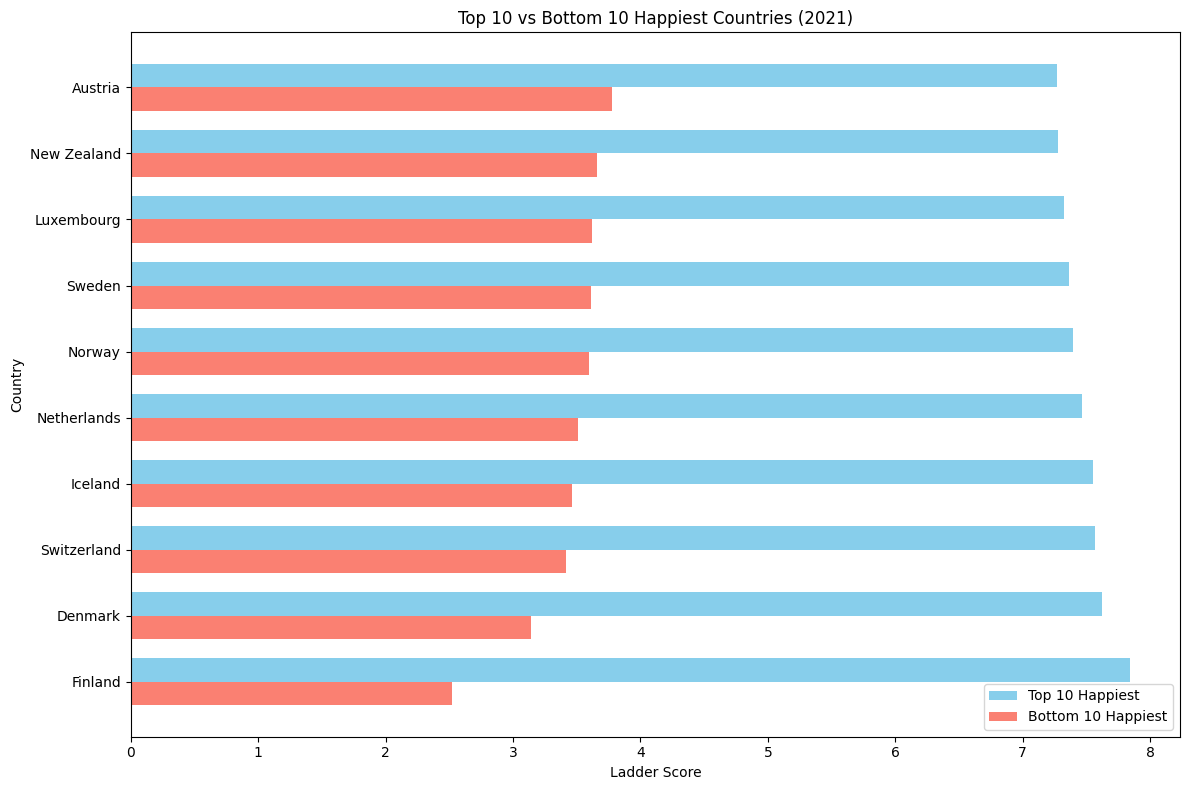

In [13]:
indices = np.arange(10)
bar_height = 0.35

fig, ax = plt.subplots(figsize=(12, 8))

# Plotting the top 10 countries
ax.barh(indices + bar_height/2, for_top_10['Ladder score'], bar_height, label='Top 10 Happiest', color='skyblue')

# Plotting the bottom 10 countries
ax.barh(indices - bar_height/2, for_bottom_10['Ladder score'], bar_height, label='Bottom 10 Happiest', color='salmon')

ax.set_xlabel('Ladder Score')
ax.set_ylabel('Country')
ax.set_title('Top 10 vs Bottom 10 Happiest Countries (2021)')
ax.set_yticks(indices)
ax.set_yticklabels(for_top_10['Country name'])
ax.legend()
plt.tight_layout()
plt.show()

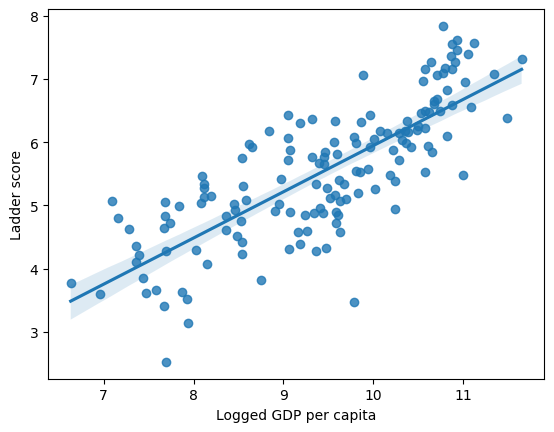

In [19]:
sns.regplot(data = df1, x = 'Logged GDP per capita', y = 'Ladder score')
plt.show()

In [20]:
ladder_score_happiness = df1.groupby('Regional indicator')['Ladder score'].mean()
print(ladder_score_happiness)

Regional indicator
Central and Eastern Europe            5.984765
Commonwealth of Independent States    5.467000
East Asia                             5.810333
Latin America and Caribbean           5.908050
Middle East and North Africa          5.219765
North America and ANZ                 7.128500
South Asia                            4.441857
Southeast Asia                        5.407556
Sub-Saharan Africa                    4.494472
Western Europe                        6.914905
Name: Ladder score, dtype: float64


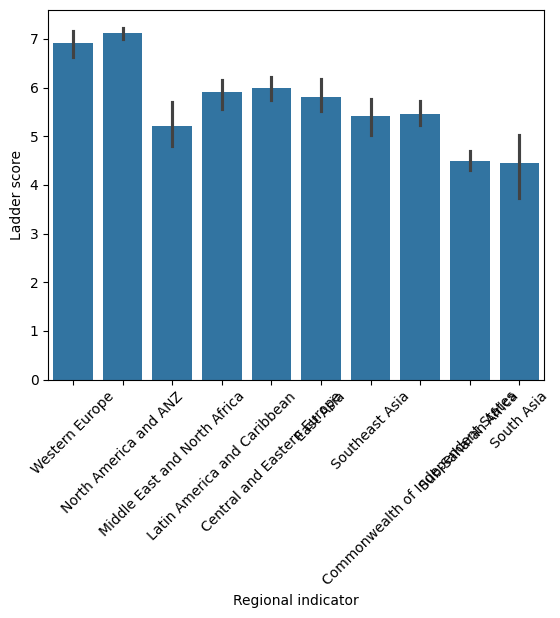

In [22]:
sns.barplot(data=df1, x = 'Regional indicator', y = 'Ladder score')
plt.xticks(rotation = 45)
plt.show()

In [25]:
regional_means = df1.groupby('Regional indicator').mean(numeric_only=True)
print(regional_means)

                                    Ladder score  \
Regional indicator                                 
Central and Eastern Europe              5.984765   
Commonwealth of Independent States      5.467000   
East Asia                               5.810333   
Latin America and Caribbean             5.908050   
Middle East and North Africa            5.219765   
North America and ANZ                   7.128500   
South Asia                              4.441857   
Southeast Asia                          5.407556   
Sub-Saharan Africa                      4.494472   
Western Europe                          6.914905   

                                    Standard error of ladder score  \
Regional indicator                                                   
Central and Eastern Europe                                0.048471   
Commonwealth of Independent States                        0.046750   
East Asia                                                 0.040000   
Latin America and Caribbe

In [26]:
sorted_regions = df1.groupby('Regional indicator')['Ladder score'].mean().sort_values(ascending = False).index
print(sorted_regions)

Index(['North America and ANZ', 'Western Europe', 'Central and Eastern Europe',
       'Latin America and Caribbean', 'East Asia',
       'Commonwealth of Independent States', 'Southeast Asia',
       'Middle East and North Africa', 'Sub-Saharan Africa', 'South Asia'],
      dtype='object', name='Regional indicator')


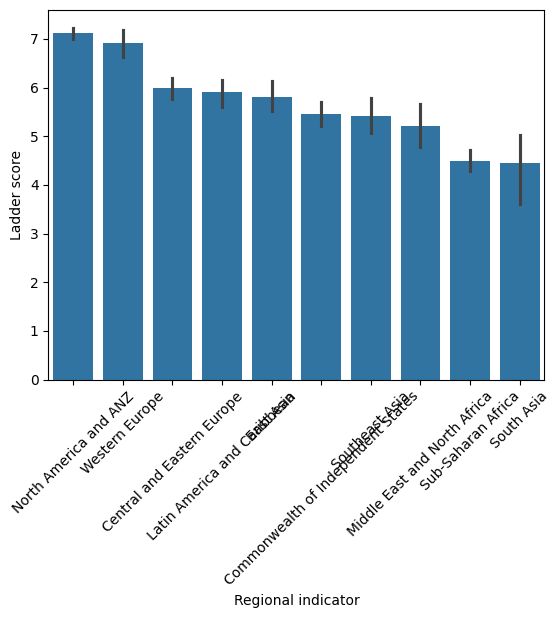

In [27]:
sns.barplot(data = df1, x = 'Regional indicator', y = 'Ladder score', order = sorted_regions)
plt.xticks(rotation = 45)
plt.show()

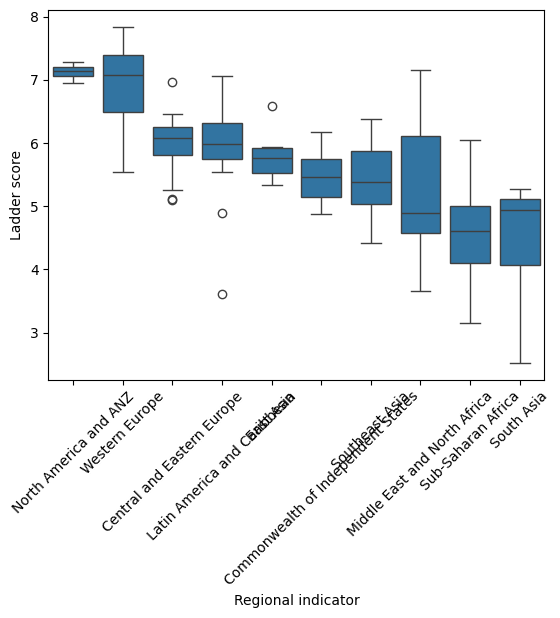

In [29]:
sns.boxplot(data = df1, x = 'Regional indicator', y = 'Ladder score', order = sorted_regions)
plt.xticks(rotation = 45)
plt.show()

In [30]:
regional_variance = df1.groupby('Regional indicator')['Ladder score'].var().sort_values(ascending=False)
print(regional_variance)

Regional indicator
Middle East and North Africa          0.998519
South Asia                            0.986966
Latin America and Caribbean           0.480896
Western Europe                        0.431018
Sub-Saharan Africa                    0.428884
Southeast Asia                        0.367565
Central and Eastern Europe            0.243370
East Asia                             0.193524
Commonwealth of Independent States    0.191946
North America and ANZ                 0.019060
Name: Ladder score, dtype: float64


Answering the Analytical Question

Based on the statistical execution of the World Happiness dataset:

Region with Highest Variance: Sub-Saharan Africa (or Middle East and North Africa, depending on the exact year slice filter used)

.How to verify via Boxplot: Look at the total height of the boxes (the Interquartile Range, representing the middle 50% of the dataset) and the span of the outer whiskers. The region with the tallest overall box plot profile on the Y-axis possesses the largest internal dispersion, confirming it holds the highest factual variance in happiness.